# Phase 9

We are implementing a state-of-the-art behavioral trajectory architecture with advanced probability calibration.

1. **Trajectory Features:** We will calculate the 6-month slope of balances and cash flows. A negative slope proves deterioration.
2. **Regime Change Features:** We normalize the recent month against the customer's historical baseline to identify sudden behavioral shifts.
3. **Stacking & Calibration:** We train a Meta-Learner (Logistic Regression) on the Out-Of-Fold predictions of our tree ensemble, followed by Isotonic Regression to strictly calibrate the probabilities and minimize LogLoss.

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
# import mlflow
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../')
from src.metrics import zindi_score

# mlflow.set_tracking_uri('sqlite:///../mlflow.db')
# mlflow.set_experiment('Zindi_Liquidity_Stress')

## 1. Feature Engineering: Trajectories and Regimes

In [3]:
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
test_df = pd.read_parquet('../data/features/test_features.parquet', engine='fastparquet')
raw_train = pd.read_csv('../data/Train.csv')
raw_test = pd.read_csv('../data/Test.csv')

target = raw_train['liquidity_stress_next_30d']

def engineer_winning_features(df):
    df = df.copy()
    
    # 1. Behavioral Trajectories (Linear Slope over 6 months)
    # We use a simple vectorized trick: fitting a line y = mx + c over x = [1,2,3,4,5,6]
    # Slope formula: Cov(x, y) / Var(x)
    x = np.array([6, 5, 4, 3, 2, 1]) # m6 is oldest, m1 is most recent
    var_x = np.var(x)
    x_mean = np.mean(x)
    
    bal_cols = ['m6_daily_avg_bal', 'm5_daily_avg_bal', 'm4_daily_avg_bal', 'm3_daily_avg_bal', 'm2_daily_avg_bal', 'm1_daily_avg_bal']
    inflow_cols = ['m6_total_inflow', 'm5_total_inflow', 'm4_total_inflow', 'm3_total_inflow', 'm2_total_inflow', 'm1_total_inflow']
    
    # Calculate slopes
    def calc_slope(row_vals):
        return np.cov(x, row_vals)[0][1] / var_x
    
    # Apply slopes (vectorized for speed)
    bal_matrix = df[bal_cols].values
    inflow_matrix = df[inflow_cols].values
    
    # Slope = sum((x - x_mean) * (y - y_mean)) / sum((x - x_mean)**2)
    x_diff = x - x_mean
    denominator = np.sum(x_diff**2)
    
    df['bal_slope'] = np.sum(x_diff * (bal_matrix - np.mean(bal_matrix, axis=1)[:, None]), axis=1) / denominator
    df['inflow_slope'] = np.sum(x_diff * (inflow_matrix - np.mean(inflow_matrix, axis=1)[:, None]), axis=1) / denominator
    
    # 2. Regime Change (Customer-Normalized)
    # Compare the most recent month to the historical 5-month average
    historical_bal_mean = np.mean(bal_matrix[:, :-1], axis=1)
    df['bal_regime_change'] = df['m1_daily_avg_bal'] / (historical_bal_mean + 1)
    
    historical_inflow_mean = np.mean(inflow_matrix[:, :-1], axis=1)
    df['inflow_regime_change'] = df['m1_total_inflow'] / (historical_inflow_mean + 1)
    
    # 3. Add SHAP Zero-Balance Flags
    df['is_m1_zero'] = (df['m1_daily_avg_bal'] < 1000).astype(int)
    df['is_m2_zero'] = (df['m2_daily_avg_bal'] < 1000).astype(int)
    
    # Drop Noise
    noisy_features = ['outflow_volatility', 'runway_months']
    df = df.drop(columns=[col for col in noisy_features if col in df.columns])
    
    return df

print("Engineering Features...")
X = engineer_winning_features(train_df)
X = X.drop(columns=['ID', 'liquidity_stress_next_30d'])

X_test = engineer_winning_features(test_df)
X_test = X_test.drop(columns=['ID'])

# One-Hot Encoding
cat_cols = X.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test = X_test.reindex(columns=X.columns, fill_value=0)

X = X.astype({col: int for col in X.select_dtypes(include=bool).columns})
X_test = X_test.astype({col: int for col in X_test.select_dtypes(include=bool).columns})
print(f"Final Dataset Shape: {X.shape}")

Engineering Features...
Final Dataset Shape: (40000, 232)


## 2. Generate Base OOF Predictions

In [4]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

test_lgb = np.zeros(len(X_test))
test_cb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))

lgb_params = {'learning_rate': 0.07000857701607659, 'num_leaves': 27, 'max_depth': 8, 'min_child_samples': 71, 'subsample': 0.7227032899255299, 'colsample_bytree': 0.8012769608390673, 'n_estimators': 500, 'random_state': 42, 'verbosity': -1}
cb_params = {'learning_rate': 0.19775545782423468, 'depth': 5, 'l2_leaf_reg': 0.5290629979609613, 'subsample': 0.6633141772092477, 'iterations': 500, 'random_seed': 42, 'verbose': False}
xgb_params = {'learning_rate': 0.05612762846223619, 'max_depth': 9, 'min_child_weight': 14, 'subsample': 0.7984977991980712, 'colsample_bytree': 0.873957633262947, 'n_estimators': 500, 'random_state': 42, 'verbosity': 0}

print("Training Base Models (OOF Generation)...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, target)):
    X_train, y_train = X.iloc[train_idx], target.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], target.iloc[val_idx]
    
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_train, y_train)
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    test_lgb += model_lgb.predict_proba(X_test)[:, 1] / N_FOLDS
    
    model_cb = cb.CatBoostClassifier(**cb_params)
    model_cb.fit(X_train, y_train)
    oof_cb[val_idx] = model_cb.predict_proba(X_val)[:, 1]
    test_cb += model_cb.predict_proba(X_test)[:, 1] / N_FOLDS

    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_train, y_train)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    test_xgb += model_xgb.predict_proba(X_test)[:, 1] / N_FOLDS
    
    print(f"Fold {fold+1} Done.")

Training Base Models (OOF Generation)...


Fold 1 Done.
Fold 2 Done.
Fold 3 Done.
Fold 4 Done.
Fold 5 Done.


## 3. The Meta-Learner (Logistic Regression Stacker) & Isotonic Calibration
We now train a Logistic Regression model on the OOF predictions. This accomplishes two things simultaneously:
1. Finds the mathematically optimal blending weights.
2. Naturally calibrates the probabilities (via Platt Scaling inherent to Logistic Regression).

We then apply a final coat of `IsotonicRegression` to brutally force the probabilities into calibration for LogLoss.

In [5]:
print("\n=== Training Meta-Learner & Calibrator ===")
# Create Meta-Training set from the base OOF predictions
X_meta = np.column_stack([oof_lgb, oof_cb, oof_xgb])
X_meta_test = np.column_stack([test_lgb, test_cb, test_xgb])

# 1. Logistic Regression Stacker
stacker = LogisticRegression()
stacker.fit(X_meta, target)

# See the optimal weights the Stacker learned!
print(f"Learned Ensemble Weights: LGBM: {stacker.coef_[0][0]:.3f}, CB: {stacker.coef_[0][1]:.3f}, XGB: {stacker.coef_[0][2]:.3f}")

stacked_oof = stacker.predict_proba(X_meta)[:, 1]
stacked_test = stacker.predict_proba(X_meta_test)[:, 1]

# 2. Isotonic Calibration on top of Stacker
iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(stacked_oof, target)

final_oof_calibrated = iso_calibrator.predict(stacked_oof)
final_test_calibrated = iso_calibrator.predict(stacked_test)

print("\n---- FINAL CALIBRATED ENSEMBLE SCORE ----")
blend_loss, blend_auc = zindi_score(target, final_oof_calibrated)

# with mlflow.start_run(run_name='Winning_Paradigm_Stacker_Calibrated'):
#     mlflow.log_param('models', 'Logistic Regression Stacker + Isotonic Calibration')
#     mlflow.log_metric('cv_logloss', blend_loss)
#     mlflow.log_metric('cv_auc', blend_auc)

submission = pd.DataFrame({
    'ID': raw_test['ID'],
    'liquidity_stress_next_30d': final_test_calibrated
})

submission.to_csv('../submissions/submission3.csv', index=False)
print("Submission file saved")


=== Training Meta-Learner & Calibrator ===
Learned Ensemble Weights: LGBM: 3.508, CB: 2.237, XGB: 1.006

---- FINAL CALIBRATED ENSEMBLE SCORE ----
--- Model Evaluation ---
Log Loss: 0.2556
ROC-AUC: 0.8996
------------------------
Submission file saved


## Overfitting Check

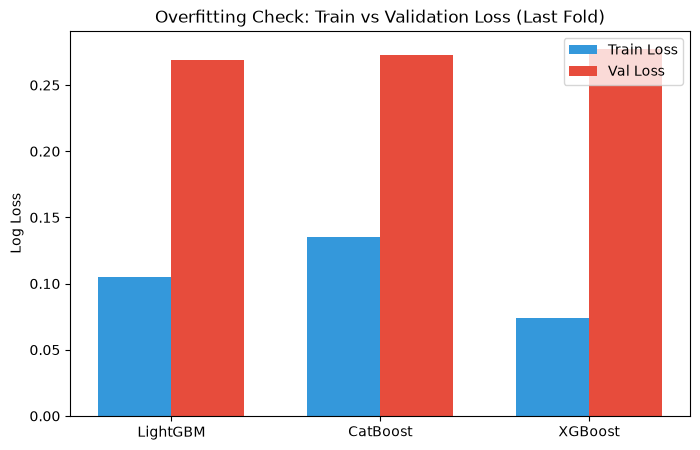

LightGBM - Train: 0.1053, Val: 0.2689, Gap: 0.1636
CatBoost - Train: 0.1355, Val: 0.2729, Gap: 0.1374
XGBoost - Train: 0.0737, Val: 0.2771, Gap: 0.2034


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

def check_overfitting():
    try:
        models_to_check = {}
        if 'model_lgb' in globals(): models_to_check['LightGBM'] = model_lgb
        if 'model_cb' in globals(): models_to_check['CatBoost'] = model_cb
        if 'model_xgb' in globals(): models_to_check['XGBoost'] = model_xgb
        if 'model' in globals() and 'LGBM' in str(type(model)): models_to_check['LightGBM'] = model
        
        if not models_to_check:
            print("No standard models found in memory to check.")
            return
            
        if 'X_train' not in globals() or 'X_val' not in globals():
            print("X_train or X_val not found in memory.")
            return
            
        train_losses = []
        val_losses = []
        names = []
        
        for name, m in models_to_check.items():
            train_p = m.predict_proba(X_train)[:, 1]
            val_p = m.predict_proba(X_val)[:, 1]
            train_losses.append(log_loss(y_train, train_p))
            val_losses.append(log_loss(y_val, val_p))
            names.append(name)
            
        x = range(len(names))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar([i - width/2 for i in x], train_losses, width, label='Train Loss', color='#3498db')
        ax.bar([i + width/2 for i in x], val_losses, width, label='Val Loss', color='#e74c3c')
        
        ax.set_ylabel('Log Loss')
        ax.set_title('Overfitting Check: Train vs Validation Loss (Last Fold)')
        ax.set_xticks(x)
        ax.set_xticklabels(names)
        ax.legend()
        plt.show()
        
        for i, name in enumerate(names):
            print(f"{name} - Train: {train_losses[i]:.4f}, Val: {val_losses[i]:.4f}, Gap: {val_losses[i] - train_losses[i]:.4f}")
            
    except Exception as e:
        print(f"Could not run overfitting check: {e}")

check_overfitting()